# Smart Loan Approval & Risk Analysis System
### A Professional, Beginner-Friendly, and Placement-Oriented End-to-End Machine Learning Notebook

---

## 1. Project Introduction

### Problem Statement
In the banking industry, loan approval is a critical decision-making process. Banks receive thousands of credit applications daily, and manually evaluating each application for risk is slow, expensive, and subject to human bias. If a bank is too conservative, it loses revenue from interest. If it is too lenient, it faces high rates of default (Non-Performing Assets or NPAs), which can lead to severe financial distress. The goal of this project is to build an automated, data-driven machine learning system that evaluates loan applications, predicts whether they should be approved or rejected, and performs a comprehensive risk analysis for each applicant.

### Business Use Case
Automating the credit underwriting process provides significant business advantages:
1. **Instant Decisioning:** Dramatically reduces the loan processing turnaround time from several days to milliseconds, improving the customer experience.
2. **Risk Mitigation:** By identifying high-risk applicants before funds are disbursed, banks can directly reduce default rates and preserve capital.
3. **Consistency and Compliance:** Ensures that every applicant is evaluated using the exact same objective logic, removing human subjectivity and ensuring compliance with fair lending standards.
4. **Optimized Resource Allocation:** Loan officers can focus their time on complex, borderline cases rather than spending hours on straightforward approvals or rejections.

### Why Banks Need Loan Approval Systems
A bank's primary source of revenue is the interest earned on loans. However, if a borrower defaults, the bank loses the remaining principal. Modern banks use machine learning models to analyze historical applicant data (income, credit history, employment status, education) and predict the likelihood of default, allowing them to make smart, risk-adjusted lending decisions.

### Real-World Applications
- **Retail Credit Cards:** Instant approval and credit limit assignment during checkout.
- **Mortgages and Auto Loans:** Underwriting systems evaluating loan-to-value (LTV) and debt-to-income (DTI) ratios.
- **FinTech Lending Platforms:** Micro-loans approved instantly based on alternative data streams.

## 2. Import Libraries

To build this machine learning pipeline, we need to import several Python libraries. Here is a brief explanation of each library and its role:
- **pandas (`pd`):** The primary tool for data manipulation and analysis. It allows us to represent dataset as tables (DataFrames) and perform operations on them.
- **numpy (`np`):** A library for scientific computing. It provides high-performance multi-dimensional array processing and mathematical utilities.
- **matplotlib.pyplot (`plt`) & seaborn (`sns`):** Libraries for data visualization. Matplotlib provides core plotting capabilities, while Seaborn offers an elegant, high-level interface for statistical graphs.
- **scikit-learn (`sklearn`):** The standard machine learning toolkit in Python. We use it for data preprocessing (scaling, encoding), splitting data, model training, evaluation, and hyperparameter tuning.
- **xgboost:** An optimized gradient boosting library that implements machine learning algorithms under the Gradient Boosting framework, known for high performance and speed.
- **joblib:** Used for serializing (saving) and deserializing (loading) trained models and preprocessing objects so they can be deployed later.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import xgboost as xgb
import joblib
import os

# Set visualization styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries successfully imported!')

Libraries successfully imported!


## 3. Load Dataset

We load the Loan Prediction dataset. To ensure this notebook runs from top to bottom without any external file uploads, we write code to check if the dataset `loan_data.csv` exists locally in the working directory; if it is missing, we automatically download it from a stable GitHub repository.

We then inspect the dataset using:
- **`shape`:** Tells us the number of rows and columns.
- **`columns`:** Displays the feature names.
- **`info()`:** Shows data types and non-null counts to check for missing values.
- **`describe()`:** Generates descriptive statistics for numerical columns (mean, std, min, max, percentiles).

In [2]:
dataset_path = 'loan_data.csv'
if not os.path.exists(dataset_path):
    print('Local dataset copy not found. Downloading from GitHub...')
    url = 'https://raw.githubusercontent.com/shrikant-temburwar/Loan-Prediction-Dataset/master/train.csv'
    df_raw = pd.read_csv(url)
    df_raw.to_csv(dataset_path, index=False)
else:
    print('Loading dataset from local copy...')
    df_raw = pd.read_csv(dataset_path)

print(f'Raw Dataset Shape: {df_raw.shape}')
print('\nRaw Dataset Columns:')
print(df_raw.columns.tolist())

# Filter columns to match the target and requested input features
target_col = 'Loan_Status'
input_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'ApplicantIncome', 
              'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']

df = df_raw[input_cols + [target_col]].copy()
print(f'\nFiltered Dataset Shape (Target + Inputs): {df.shape}')

Loading dataset from local copy...
Raw Dataset Shape: (614, 13)

Raw Dataset Columns:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Filtered Dataset Shape (Target + Inputs): (614, 11)


In [3]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    object 
 1   Married            611 non-null    object 
 2   Education          614 non-null    object 
 3   Self_Employed      582 non-null    object 
 4   ApplicantIncome    614 non-null    int64  
 5   CoapplicantIncome  614 non-null    float64
 6   LoanAmount         592 non-null    float64
 7   Loan_Amount_Term   600 non-null    float64
 8   Credit_History     564 non-null    float64
 9   Property_Area      614 non-null    object 
 10  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(6)
memory usage: 52.9+ KB


In [ ]:
# Generate statistical summary of the features
df.describe(include='all')

## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis helps us understand relationships, distributions, and patterns in our data before applying machine learning algorithms. In this section, we generate and explain several visualizations:
1. **Missing Values Analysis:** Identifies columns containing missing data to plan our imputation strategy.
2. **Loan Approval Distribution:** A countplot representing the distribution of the target variable `Loan_Status` (class balance/imbalance).
3. **Income Distributions:** Histograms and boxplots showing the spread, skewness, and outliers of `ApplicantIncome` and `CoapplicantIncome`.
4. **Loan Amount Distribution:** Analyzing the range of loan amounts requested by applicants.
5. **Credit History Analysis:** Segregating the loan approval rate based on whether the applicant met historical credit guidelines.
6. **Categorical Feature Distribution:** Visualizing demographics (Gender, Married, Education, Employment, Property Area) against loan status.
7. **Boxplots:** Checking income variations across education levels and loan approval decisions.
8. **Correlation Heatmap:** A linear correlation plot showing relationships between numerical features.

### 4.1 Missing Values Analysis

We calculate the number of missing values per column and plot them. This visualization highlights columns that require data cleaning.

Missing Values Count per Column:
Gender              13
Married              3
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50
dtype: int64


C:\Users\vivek\AppData\Local\Temp\ipykernel_11728\2806342698.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='viridis')


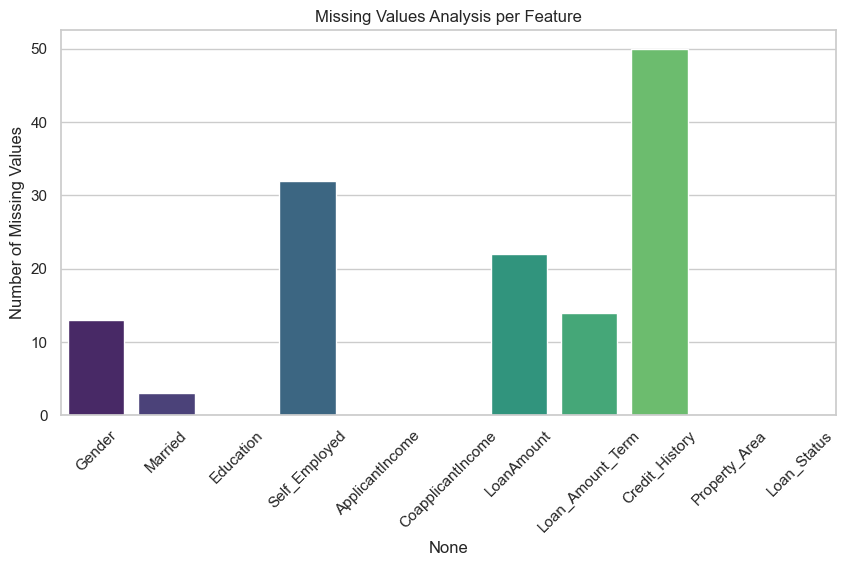

In [4]:
missing_counts = df.isnull().sum()
print('Missing Values Count per Column:')
print(missing_counts[missing_counts > 0])

plt.figure(figsize=(10, 5))
sns.barplot(x=missing_counts.index, y=missing_counts.values, palette='viridis')
plt.title('Missing Values Analysis per Feature')
plt.xticks(rotation=45)
plt.ylabel('Number of Missing Values')
plt.show()

### 4.2 Loan Approval Distribution (Target Class)

We plot a countplot of `Loan_Status` (`Y` for approved, `N` for rejected) to check for class imbalance. Imbalanced datasets (e.g. 90% approvals, 10% rejections) require careful metric evaluation.

C:\Users\vivek\AppData\Local\Temp\ipykernel_11728\661100919.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Loan_Status', palette='Set2')


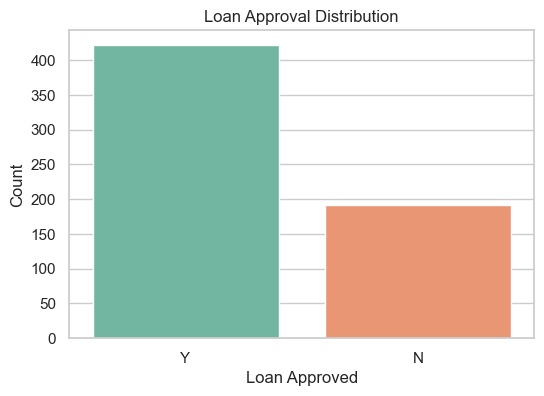

Approval Rate: Approved (Y) = 68.73%, Rejected (N) = 31.27%


In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Loan_Status', palette='Set2')
plt.title('Loan Approval Distribution')
plt.xlabel('Loan Approved')
plt.ylabel('Count')
plt.show()

approval_pct = df['Loan_Status'].value_counts(normalize=True) * 100
print(f"Approval Rate: Approved (Y) = {approval_pct['Y']:.2f}%, Rejected (N) = {approval_pct['N']:.2f}%")

### 4.3 Income Distribution & Outlier Detection

We plot histograms with Kernel Density Estimation (KDE) and boxplots for `ApplicantIncome` and `CoapplicantIncome` to look at skewness. Skewed distributions indicate that most applicants earn within a specific range, but a few make significantly more (outliers).

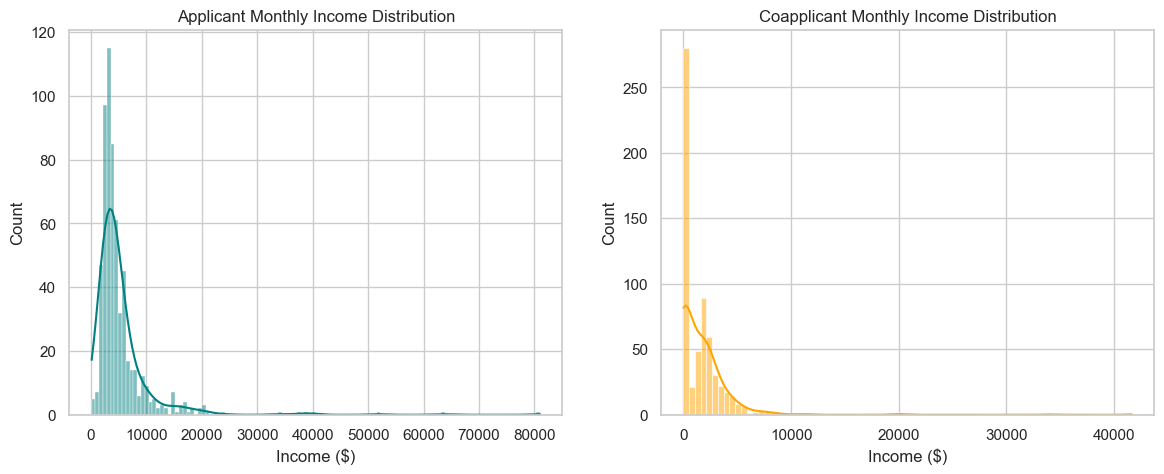

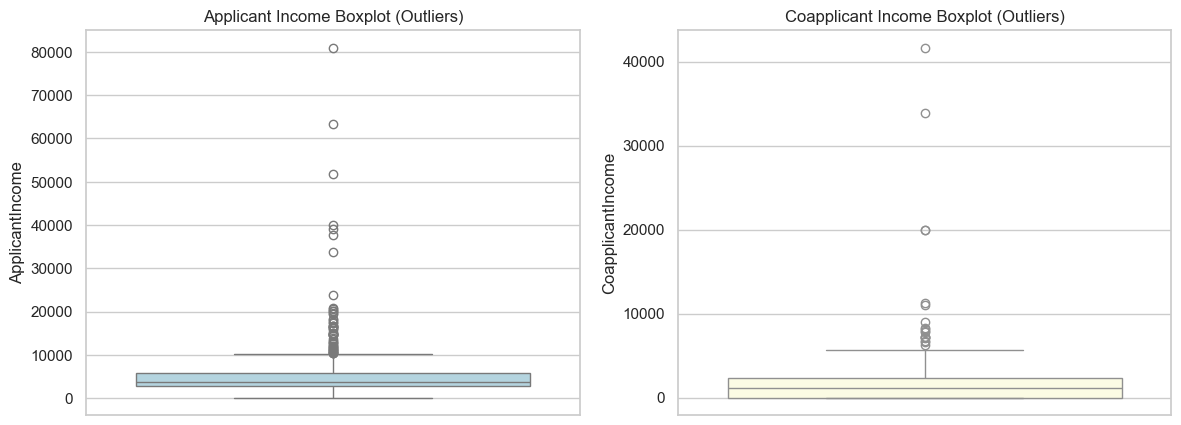

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['ApplicantIncome'], kde=True, color='teal', ax=axes[0])
axes[0].set_title('Applicant Monthly Income Distribution')
axes[0].set_xlabel('Income ($)')

sns.histplot(df['CoapplicantIncome'].dropna(), kde=True, color='orange', ax=axes[1])
axes[1].set_title('Coapplicant Monthly Income Distribution')
axes[1].set_xlabel('Income ($)')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, y='ApplicantIncome', color='lightblue', ax=axes[0])
axes[0].set_title('Applicant Income Boxplot (Outliers)')

sns.boxplot(data=df, y='CoapplicantIncome', color='lightyellow', ax=axes[1])
axes[1].set_title('Coapplicant Income Boxplot (Outliers)')
plt.show()

### 4.4 Loan Amount Distribution

We visualize the requested `LoanAmount` (in thousands of dollars) using a histogram and a boxplot to evaluate range and skewness.

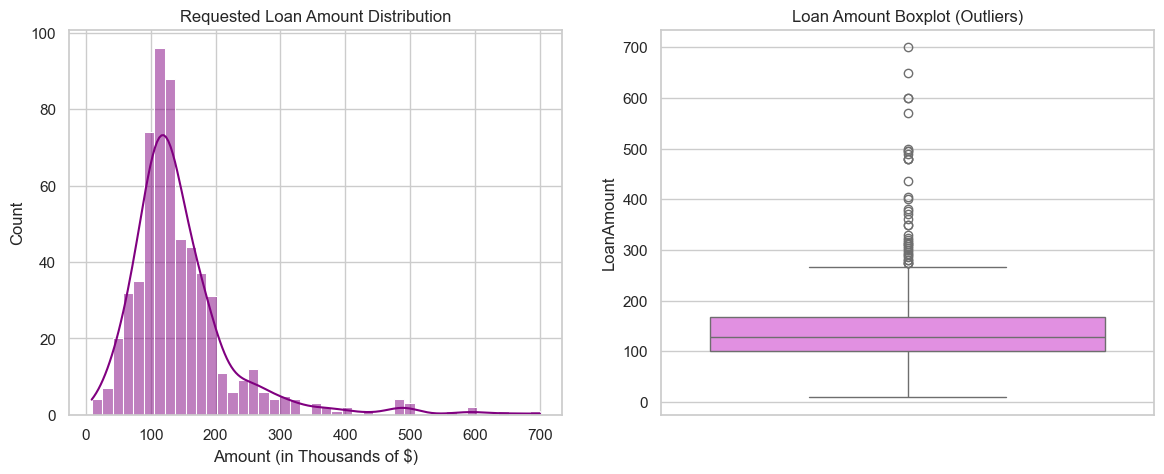

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['LoanAmount'].dropna(), kde=True, color='purple', ax=axes[0])
axes[0].set_title('Requested Loan Amount Distribution')
axes[0].set_xlabel('Amount (in Thousands of $)')

sns.boxplot(data=df, y='LoanAmount', color='violet', ax=axes[1])
axes[1].set_title('Loan Amount Boxplot (Outliers)')
plt.show()

### 4.5 Credit History Analysis

Credit History represents whether the applicant meets standard lending credit guidelines (1 = Yes, 0 = No). We plot this variable segmented by `Loan_Status` to evaluate its relationship with approvals.

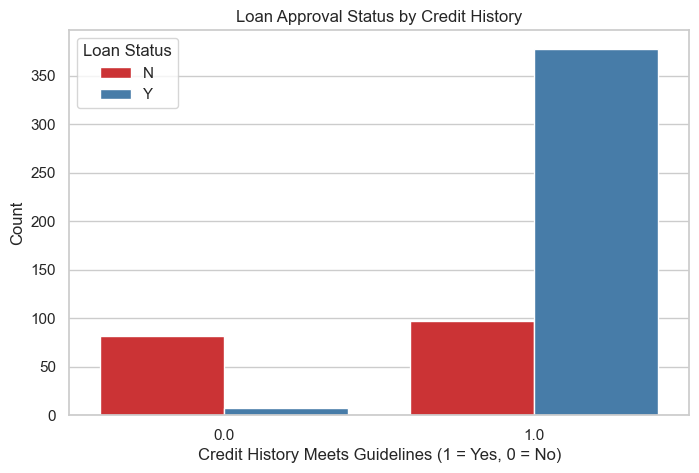

Approval Rate by Credit History Profile:
Loan_Status             N          Y
Credit_History                      
0.0             92.134831   7.865169
1.0             20.421053  79.578947


In [8]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Credit_History', hue='Loan_Status', palette='Set1')
plt.title('Loan Approval Status by Credit History')
plt.xlabel('Credit History Meets Guidelines (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.legend(title='Loan Status')
plt.show()

# Output approval rate percentage per Credit History score
ct = pd.crosstab(df['Credit_History'], df['Loan_Status'], normalize='index') * 100
print('Approval Rate by Credit History Profile:')
print(ct)

### 4.6 Countplots of Categorical Inputs

We visualize categorical features (`Gender`, `Married`, `Education`, `Self_Employed`, `Property_Area`) segmented by the target `Loan_Status` to observe social and demographic distributions.

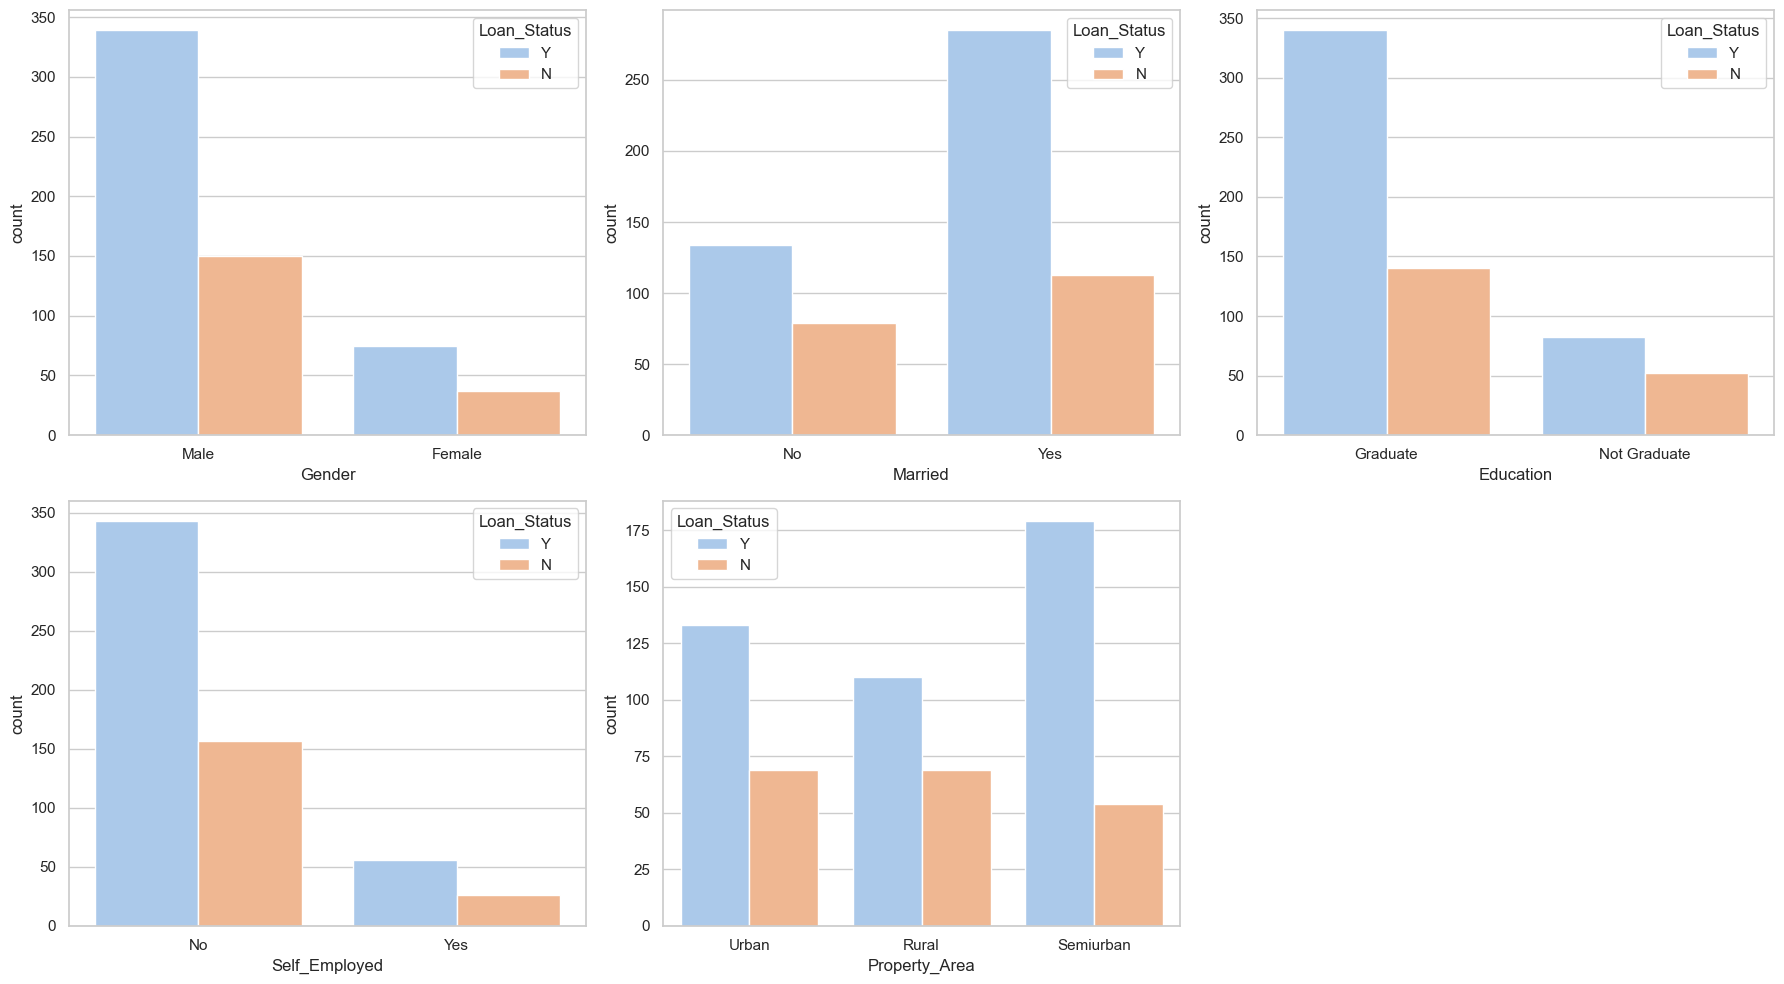

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
sns.countplot(data=df, x='Gender', hue='Loan_Status', ax=axes[0, 0], palette='pastel')
sns.countplot(data=df, x='Married', hue='Loan_Status', ax=axes[0, 1], palette='pastel')
sns.countplot(data=df, x='Education', hue='Loan_Status', ax=axes[0, 2], palette='pastel')
sns.countplot(data=df, x='Self_Employed', hue='Loan_Status', ax=axes[1, 0], palette='pastel')
sns.countplot(data=df, x='Property_Area', hue='Loan_Status', ax=axes[1, 1], palette='pastel')
axes[1, 2].axis('off')  # Disable the empty corner subplot
plt.tight_layout()
plt.show()

### 4.7 Boxplots of Income vs Education & Property Area

We plot Boxplots to check if an applicant's education matches income, and if the requested loan amount varies across property areas.

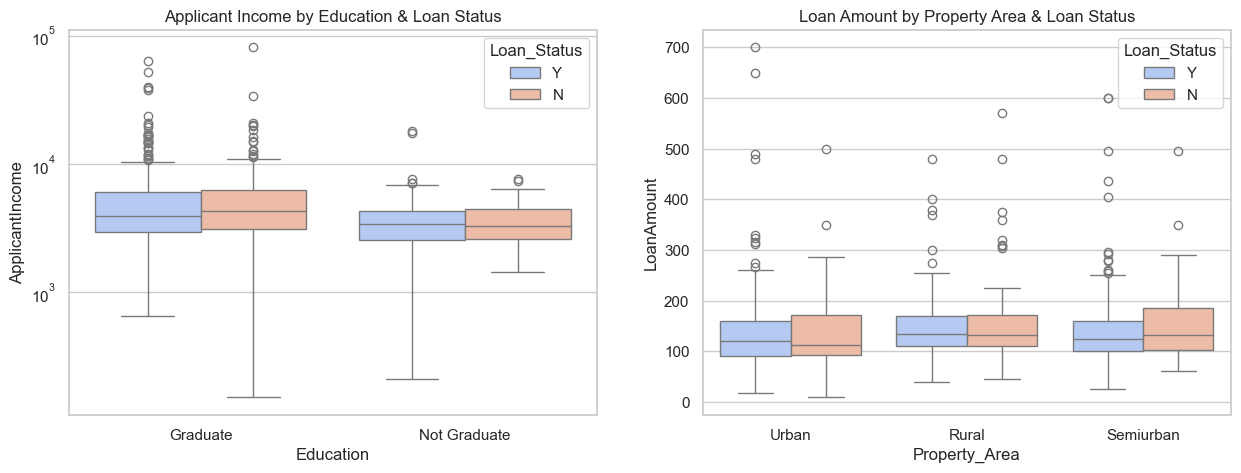

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x='Education', y='ApplicantIncome', hue='Loan_Status', palette='coolwarm', ax=axes[0])
axes[0].set_title('Applicant Income by Education & Loan Status')
axes[0].set_yscale('log')  # Log scale for readability due to extreme income outliers

sns.boxplot(data=df, x='Property_Area', y='LoanAmount', hue='Loan_Status', palette='coolwarm', ax=axes[1])
axes[1].set_title('Loan Amount by Property Area & Loan Status')
plt.show()

### 4.8 Correlation Heatmap

We compute linear correlation values between numerical columns and plot them as a heatmap. Values close to `1.0` or `-1.0` indicate strong linear dependencies.

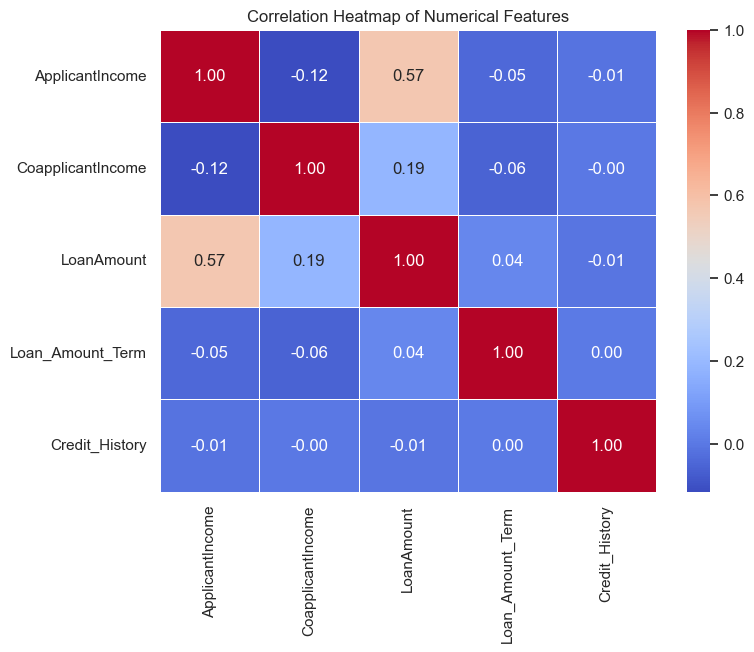

In [11]:
plt.figure(figsize=(8, 6))
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## 5. Data Cleaning

Real-world datasets contain missing entries. We must fill (impute) them before model training. Let's compare the three standard methods:
1. **Mean:** The mathematical average. Highly sensitive to outliers. Not recommended for skewed distributions (like `ApplicantIncome` or `LoanAmount`).
2. **Median:** The middle value. Robust to outliers. Ideal for skewed numerical variables.
3. **Mode:** The most frequent category. Recommended for categorical columns and discrete/binary variables.

### Selection Strategy:
- `LoanAmount`: Imputed using the **Median** because the distribution is highly right-skewed with extreme outliers.
- `Loan_Amount_Term` & `Credit_History`: Imputed using the **Mode** because they are discrete numeric representations of categories or time terms (e.g. 360 months).
- `Gender`, `Married`, `Self_Employed`: Imputed using the **Mode** since they are categorical.

In [12]:
print('Null counts before cleaning:')
print(df.isnull().sum())

# Impute numerical values
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

# Impute discrete numerical values with Mode
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# Impute categorical values with Mode
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

print('\nNull counts after cleaning:')
print(df.isnull().sum())

Null counts before cleaning:
Gender               13
Married               3
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Null counts after cleaning:
Gender               0
Married              0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


## 6. Feature Engineering

Feature Engineering is the process of using domain knowledge to create new features that make it easier for machine learning models to learn patterns. We create two new columns:
1. **`Total_Income`:** Combines `ApplicantIncome` and `CoapplicantIncome`. This reflects the applicant household's combined repaying capacity.
2. **`Income_to_Loan_Ratio`:** The ratio of `Total_Income` to `LoanAmount` ($Total\_Income / LoanAmount$). A higher ratio indicates the applicant earns significantly more than they are borrowing, representing a lower default risk.

In [13]:
df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['Income_to_Loan_Ratio'] = df['Total_Income'] / df['LoanAmount']

print('Feature Engineering complete. Sample outputs:')
print(df[['ApplicantIncome', 'CoapplicantIncome', 'Total_Income', 'LoanAmount', 'Income_to_Loan_Ratio']].head())

Feature Engineering complete. Sample outputs:
   ApplicantIncome  CoapplicantIncome  Total_Income  LoanAmount  \
0             5849                0.0        5849.0       128.0   
1             4583             1508.0        6091.0       128.0   
2             3000                0.0        3000.0        66.0   
3             2583             2358.0        4941.0       120.0   
4             6000                0.0        6000.0       141.0   

   Income_to_Loan_Ratio  
0             45.695312  
1             47.585938  
2             45.454545  
3             41.175000  
4             42.553191  


## 7. Encoding Categorical Variables

Machine Learning algorithms only accept numerical values. Categorical variables must be converted:
- **Label Encoding:** Converts categories to sequential integers (e.g. Male -> 0, Female -> 1). We apply this to binary columns: `Gender`, `Married`, `Education`, and `Self_Employed`.
- **One-Hot Encoding:** Creates binary columns (0 or 1) for each category. We apply this to the multiclass variable `Property_Area` (Rural, Semiurban, Urban) to avoid introducing false numerical order.

We save the encoder objects in a dictionary as `encoder.pkl` to transform future inputs in Phase 2.

In [14]:
encoders = {}

# Apply LabelEncoder for binary features
binary_cols = ['Gender', 'Married', 'Education', 'Self_Employed']
for col in binary_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le
    print(f"{col} Encoded classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Apply OneHotEncoder for Property_Area
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
ohe_features = ohe.fit_transform(df[['Property_Area']])
ohe_cols = [f"Property_Area_{cat}" for cat in ohe.categories_[0]]
ohe_df = pd.DataFrame(ohe_features, columns=ohe_cols, index=df.index)

# Join one-hot encoded columns and drop raw Property_Area
df = pd.concat([df.drop(columns=['Property_Area']), ohe_df], axis=1)
encoders['Property_Area'] = ohe
encoders['ohe_cols'] = ohe_cols
print(f"One-Hot Encoded Property_Area: created columns {ohe_cols}")

# Encode the target Loan_Status column (Y -> 1, N -> 0)
target_le = LabelEncoder()
df['Loan_Status'] = target_le.fit_transform(df['Loan_Status'])
encoders['Loan_Status'] = target_le
print(f"Target encoded: Y -> {target_le.transform(['Y'])[0]}, N -> {target_le.transform(['N'])[0]}")

# Save encoders dictionary to file
joblib.dump(encoders, 'encoder.pkl')
print('All encoders successfully saved to encoder.pkl')

Gender Encoded classes: {'Female': np.int64(0), 'Male': np.int64(1)}
Married Encoded classes: {'No': np.int64(0), 'Yes': np.int64(1)}
Education Encoded classes: {'Graduate': np.int64(0), 'Not Graduate': np.int64(1)}
Self_Employed Encoded classes: {'No': np.int64(0), 'Yes': np.int64(1)}
One-Hot Encoded Property_Area: created columns ['Property_Area_Rural', 'Property_Area_Semiurban', 'Property_Area_Urban']
Target encoded: Y -> 1, N -> 0
All encoders successfully saved to encoder.pkl


## 8. Feature Scaling

### Why Scaling is Required
Numerical variables like `Total_Income` are in the thousands, while `Credit_History` is binary (0 or 1). Distance-based models (e.g. KNN, SVM) and gradient-descent optimized models (e.g. Logistic Regression) will consider larger-scaled features as more important. Feature scaling maps them to a uniform scale.

### Which Models Benefit From Scaling
- **Logistic Regression:** Converges faster with scaled features.
- **Tree-based Models (Decision Trees, Random Forest, XGBoost):** Invariant to scale because splits are made on individual features. We still scale features so that all models are compared fairly.

We use `StandardScaler` to standardize our numerical columns: $z = \frac{x - \mu}{\sigma}$
To avoid **Data Leakage**, we initialize the scaler here but fit it ONLY on the training split in the next section.

In [15]:
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Total_Income', 'Income_to_Loan_Ratio']
print('Numerical features to scale:', num_cols)

Numerical features to scale: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Total_Income', 'Income_to_Loan_Ratio']


## 9. Train Test Split & Scaling Fitting

We separate the features (`X`) and the target variable (`y`). We then split the data into 80% training and 20% testing sets.

### Key Concepts:
- **Training Data:** Used to train the model.
- **Testing Data:** Held-out data used to evaluate how the model performs on unseen profiles.
- **Overfitting:** When a model memorizes the training data but fails to generalize to test data.
- **Data Leakage:** When information from the test dataset is used during training or preprocessing. For instance, fitting the scaler on the whole dataset allows test set statistics (mean/std) to leak into training. To prevent this, we **fit** the `StandardScaler` on `X_train` only, then **transform** both `X_train` and `X_test`.

In [16]:
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

# Perform Train-Test Split (using stratification to maintain class proportions)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Initialize and Fit scaler ONLY on training data
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Save fitted scaler to file
joblib.dump(scaler, 'scaler.pkl')
print('Scaler successfully fitted on X_train, applied to train/test, and saved to scaler.pkl')

print('\nSample scaled training data:')
print(X_train[num_cols].head(3))

X_train shape: (491, 14)
X_test shape: (123, 14)
Scaler successfully fitted on X_train, applied to train/test, and saved to scaler.pkl

Sample scaled training data:
     ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
154        -0.352802          -0.563228   -1.131588          0.280691   
239        -0.343346          -0.563228   -0.592309          0.280691   
448        -0.339471           0.050405    0.040758          0.280691   

     Total_Income  Income_to_Loan_Ratio  
154     -0.575168              0.436425  
239     -0.566044             -0.488055  
448     -0.306544             -0.514219  


## 10. Train Multiple Models

We train four classifiers to evaluate their predictive capabilities:

### 1. Logistic Regression
- **Intuition:** Fits a linear boundary and maps output to a probability using the logistic sigmoid function. Easy to interpret and serves as a strong baseline.

### 2. Decision Tree Classifier
- **Intuition:** Splits the dataset on feature rules to group similar samples. Easy to visualize but prone to overfitting.

### 3. Random Forest Classifier
- **Intuition:** Builds an ensemble of multiple independent decision trees on bootstrap samples of the data and averages their predictions to reduce variance.

### 4. XGBoost Classifier
- **Intuition:** An optimized gradient boosting implementation. It trains trees sequentially, where each tree learns from and corrects the errors of its predecessor.

In [17]:
# Initialize classifiers
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, eval_metric='logloss', random_state=42)
}

# Dictionaries to store results
predictions = {}
probabilities = {}

# Fit models and make predictions
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    # Get probabilities of approval (class 1)
    probabilities[name] = model.predict_proba(X_test)[:, 1]
    print(f"{name} successfully trained!")

Logistic Regression successfully trained!
Decision Tree successfully trained!
Random Forest successfully trained!
XGBoost successfully trained!


## 11. Model Evaluation

We evaluate our classifiers using five metrics:
- **Accuracy:** Overal percentage of correct predictions. (Formula: $\frac{TP+TN}{TP+TN+FP+FN}$)
- **Precision:** Out of all applications predicted as approved, how many were actually creditworthy? (Formula: $\frac{TP}{TP+FP}$)
- **Recall:** Out of all actual creditworthy applications, how many did we approve? (Formula: $\frac{TP}{TP+FN}$)
- **F1 Score:** Harmonic mean of Precision and Recall. (Formula: $2 \times \frac{Precision \times Recall}{Precision + Recall}$)
- **ROC AUC:** Measures class separation capacity across all decision thresholds. Closer to 1 is better.

We compile these metrics into a comparison table to select our best-performing model.

In [18]:
evaluation_metrics = []

for name in models.keys():
    acc = accuracy_score(y_test, predictions[name])
    prec = precision_score(y_test, predictions[name])
    rec = recall_score(y_test, predictions[name])
    f1 = f1_score(y_test, predictions[name])
    roc_auc = roc_auc_score(y_test, probabilities[name])
    
    evaluation_metrics.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    })

metrics_df = pd.DataFrame(evaluation_metrics)
print('Model Comparison Table:')
print(metrics_df.round(4))

Model Comparison Table:
                 Model  Accuracy  Precision  Recall  F1 Score  ROC AUC
0  Logistic Regression    0.8618     0.8400  0.9882    0.9081   0.8495
1        Decision Tree    0.8537     0.8454  0.9647    0.9011   0.7477
2        Random Forest    0.8699     0.8485  0.9882    0.9130   0.8684
3              XGBoost    0.8780     0.8804  0.9529    0.9153   0.8337


In [19]:
# Find champion model based on accuracy
best_model_idx = metrics_df['Accuracy'].idxmax()
best_model_name = metrics_df.loc[best_model_idx, 'Model']
best_model_acc = metrics_df.loc[best_model_idx, 'Accuracy']
print(f"Champion Model: {best_model_name} with Accuracy: {best_model_acc:.4f}")

Champion Model: XGBoost with Accuracy: 0.8780


## 12. Hyperparameter Tuning

### Cross Validation (CV) Explained
To find the optimal hyperparameters without overfitting to the test set, we use **K-Fold Cross Validation**. The training set is split into $K$ equal subsets (folds). The model is trained on $K-1$ folds and validated on the remaining fold. This is repeated $K$ times, and the average validation score determines performance.

We use `GridSearchCV` to run cross validation across a grid of parameter combinations on our champion model, optimizing its configuration.

In [20]:
print(f"Tuning hyperparameters for {best_model_name} using Grid Search CV...")

# Setup parameter grids depending on the champion model type
if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 5, 8, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    base_estimator = RandomForestClassifier(random_state=42)
elif best_model_name == 'XGBoost':
    param_grid = {
        'n_estimators': [50, 100, 150],
        'max_depth': [3, 4, 5, 6],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.8, 1.0]
    }
    base_estimator = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
elif best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'penalty': ['l2']
    }
    base_estimator = LogisticRegression(max_iter=1000, random_state=42)
else:
    param_grid = {
        'max_depth': [3, 5, 8, 10, None],
        'min_samples_split': [2, 5, 10]
    }
    base_estimator = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(estimator=base_estimator, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

tuned_model = grid_search.best_estimator_
tuned_predictions = tuned_model.predict(X_test)
tuned_probs = tuned_model.predict_proba(X_test)[:, 1]

tuned_acc = accuracy_score(y_test, tuned_predictions)
tuned_f1 = f1_score(y_test, tuned_predictions)

print(f"Optimal Parameters found: {grid_search.best_params_}")
print(f"Baseline Accuracy: {best_model_acc:.4f} -> Tuned Accuracy: {tuned_acc:.4f}")
print(f"Tuned F1 Score: {tuned_f1:.4f}")

Tuning hyperparameters for XGBoost using Grid Search CV...
Optimal Parameters found: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50, 'subsample': 0.8}
Baseline Accuracy: 0.8780 -> Tuned Accuracy: 0.8537
Tuned F1 Score: 0.9032


## 13. Feature Importance

Feature Importance helps explain how our models make decisions by identifying which inputs have the greatest impact on predictions. We will compute and plot feature importances for both our **Random Forest** and **XGBoost** classifiers.

C:\Users\vivek\AppData\Local\Temp\ipykernel_11728\1657396080.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, y='Feature', x='Random Forest', ax=axes[0], palette='Blues_r')
C:\Users\vivek\AppData\Local\Temp\ipykernel_11728\1657396080.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.sort_values(by='XGBoost', ascending=False), y='Feature', x='XGBoost', ax=axes[1], palette='Oranges_r')


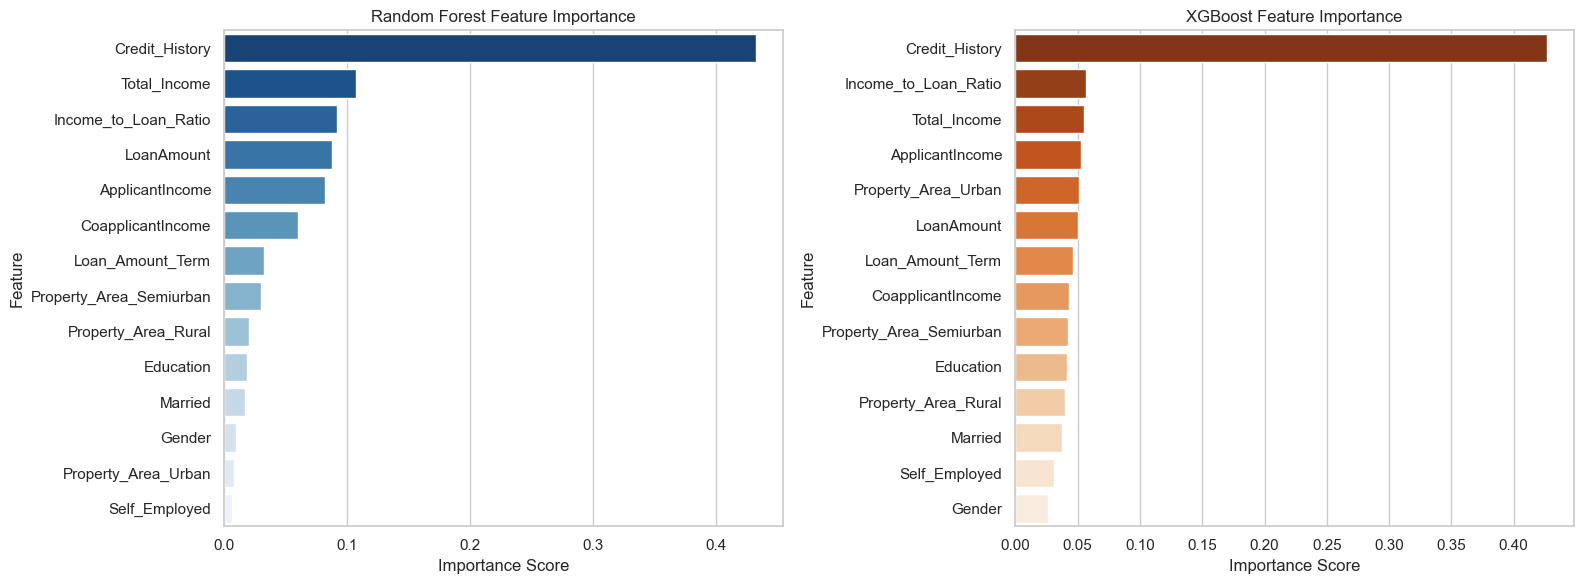

Top 3 factors affecting loan approval (based on Random Forest):
['Credit_History', 'Total_Income', 'Income_to_Loan_Ratio']


In [22]:
rf_model = models['Random Forest']
xgb_model = models['XGBoost']

rf_importances = rf_model.feature_importances_
xgb_importances = xgb_model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Random Forest': rf_importances,
    'XGBoost': xgb_importances
}).sort_values(by='Random Forest', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=importance_df, y='Feature', x='Random Forest', ax=axes[0], palette='Blues_r')
axes[0].set_title('Random Forest Feature Importance')
axes[0].set_xlabel('Importance Score')

sns.barplot(data=importance_df.sort_values(by='XGBoost', ascending=False), y='Feature', x='XGBoost', ax=axes[1], palette='Oranges_r')
axes[1].set_title('XGBoost Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

print('Top 3 factors affecting loan approval (based on Random Forest):')
print(importance_df['Feature'].head(3).tolist())

## 14. Risk Analysis Module

In banking, assigning risk ratings based on the predicted probability of approval helps in tiered pricing, determining interest rates, and flagging borderline cases.

We implement custom risk scoring rules based on the probability of approval ($P_{approval}$):
- **High Risk:** $P_{approval} < 30\%$ (The model is highly confident the borrower is a default risk).
- **Medium Risk:** $30\% \le P_{approval} \le 70\%$ (Borderline case, needs manual review).
- **Low Risk:** $P_{approval} > 70\%$ (Borrower has excellent creditworthiness).

In [23]:
risk_samples = X_test.copy()
risk_samples['Actual_Status'] = y_test.values
risk_samples['Approval_Probability'] = tuned_probs
risk_samples['Predicted_Status'] = tuned_predictions

def classify_risk(prob):
    pct = prob * 100
    if pct < 30:
        return 'High Risk'
    elif pct <= 70:
        return 'Medium Risk'
    else:
        return 'Low Risk'

risk_samples['Risk_Level'] = risk_samples['Approval_Probability'].apply(classify_risk)

# Map encoded labels back for display
risk_samples['Actual_Status'] = risk_samples['Actual_Status'].map({1: 'Approved', 0: 'Rejected'})
risk_samples['Predicted_Status'] = risk_samples['Predicted_Status'].map({1: 'Approved', 0: 'Rejected'})

print('Sample Risk Assessments from Test Set:')
print(risk_samples[['Approval_Probability', 'Risk_Level', 'Predicted_Status', 'Actual_Status']].head(10))

Sample Risk Assessments from Test Set:
     Approval_Probability Risk_Level Predicted_Status Actual_Status
150              0.097687  High Risk         Rejected      Rejected
559              0.798576   Low Risk         Approved      Approved
598              0.737767   Low Risk         Approved      Approved
235              0.722837   Low Risk         Approved      Approved
145              0.839210   Low Risk         Approved      Approved
191              0.759982   Low Risk         Approved      Rejected
557              0.811504   Low Risk         Approved      Approved
470              0.868337   Low Risk         Approved      Approved
88               0.742777   Low Risk         Approved      Approved
386              0.850218   Low Risk         Approved      Approved


## 15. Save Final Artifacts

To make this model production-ready, we serialize our final pipeline components using `joblib`:
1. **`loan_model.pkl`:** The tuned champion model.
2. **`scaler.pkl`:** The `StandardScaler` fitted on the training data.
3. **`encoder.pkl`:** The dictionary containing our binary label encoders, multiclass one-hot encoders, and column listings.

### Why are these files needed later?
When we deploy this model via a Flask API (Phase 2), the API will receive raw user inputs (e.g. `Gender: 'Male'`, `ApplicantIncome: 5000`). It needs to perform the exact same preprocessing (imputation, label encoding, one-hot encoding, scaling, and feature engineering) as was done during training. Re-using these saved files prevents **concept drift** and avoids having to retrain the model on every incoming request.

In [24]:
# Save the tuned best model
joblib.dump(tuned_model, 'loan_model.pkl')
print('Model saved successfully to loan_model.pkl')

# Confirm all three files exist
files_to_check = ['loan_model.pkl', 'scaler.pkl', 'encoder.pkl']
print('\nArtifact verification status:')
for f in files_to_check:
    status = 'Exists' if os.path.exists(f) else 'NOT FOUND'
    print(f'- {f}: {status}')

Model saved successfully to loan_model.pkl

Artifact verification status:
- loan_model.pkl: Exists
- scaler.pkl: Exists
- encoder.pkl: Exists


## 16. Build Reusable Prediction Function

We build an end-to-end, reusable function `predict_loan()` that accepts raw user input values, preprocesses them using our serialized scaling and encoding objects, makes predictions, and assigns a risk category.

In [25]:
def predict_loan(raw_input):
    """
    Accepts a dictionary of raw input features.
    Returns a prediction decision (Approved/Rejected), the confidence probability, and the risk rating.
    """
    # Load models and preprocessing objects
    model = joblib.load('loan_model.pkl')
    scaler = joblib.load('scaler.pkl')
    encoders = joblib.load('encoder.pkl')
    
    # Create DataFrame from inputs
    input_df = pd.DataFrame([raw_input])
    
    # Define system defaults in case of missing inputs
    defaults = {
        'Gender': 'Male',
        'Married': 'No',
        'Education': 'Graduate',
        'Self_Employed': 'No',
        'ApplicantIncome': 4000.0,
        'CoapplicantIncome': 0.0,
        'LoanAmount': 120.0,
        'Loan_Amount_Term': 360.0,
        'Credit_History': 1.0,
        'Property_Area': 'Semiurban'
    }
    
    # Fill any missing keys with default values
    for col in defaults:
        if col not in input_df.columns:
            input_df[col] = defaults[col]
            
    # Apply Categorical LabelEncoding (binary columns)
    binary_cols = ['Gender', 'Married', 'Education', 'Self_Employed']
    for col in binary_cols:
        le = encoders[col]
        input_df[col] = le.transform(input_df[col].astype(str))
        
    # Apply OneHotEncoding for Property_Area
    ohe = encoders['Property_Area']
    ohe_cols = encoders['ohe_cols']
    ohe_features = ohe.transform(input_df[['Property_Area']])
    ohe_df = pd.DataFrame(ohe_features, columns=ohe_cols, index=input_df.index)
    
    # Drop original multiclass column and concat one-hot features
    input_df = pd.concat([input_df.drop(columns=['Property_Area']), ohe_df], axis=1)
    
    # Perform Feature Engineering
    input_df['Total_Income'] = input_df['ApplicantIncome'] + input_df['CoapplicantIncome']
    
    loan_amt = input_df['LoanAmount'].values[0]
    if loan_amt == 0:
        input_df['Income_to_Loan_Ratio'] = 0.0
    else:
        input_df['Income_to_Loan_Ratio'] = input_df['Total_Income'] / loan_amt
        
    # Scale numerical features using loaded scaler
    num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Total_Income', 'Income_to_Loan_Ratio']
    input_df[num_cols] = scaler.transform(input_df[num_cols])
    
    # Arrange features in the exact training sequence
    feature_cols = [
        'Gender', 'Married', 'Education', 'Self_Employed', 
        'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 
        'Credit_History', 'Total_Income', 'Income_to_Loan_Ratio',
        'Property_Area_Rural', 'Property_Area_Semiurban', 'Property_Area_Urban'
    ]
    
    input_df = input_df[feature_cols]
    
    # Run Prediction
    pred = model.predict(input_df)[0]
    prob = model.predict_proba(input_df)[0][1] # Probability of Approval (class 1)
    
    # Risk scoring assignment
    prob_percentage = prob * 100
    if prob_percentage < 30:
        risk_level = 'High Risk'
    elif prob_percentage <= 70:
        risk_level = 'Medium Risk'
    else:
        risk_level = 'Low Risk'
        
    prediction_label = 'Approved' if pred == 1 else 'Rejected'
    
    return {
        'prediction': prediction_label,
        'probability': round(prob_percentage, 2),
        'risk_level': risk_level
    }

# Define sample inputs representing different risk profiles
low_risk_applicant = {
    'Gender': 'Male',
    'Married': 'Yes',
    'Education': 'Graduate',
    'Self_Employed': 'No',
    'ApplicantIncome': 6000,
    'CoapplicantIncome': 3000,
    'LoanAmount': 120,
    'Loan_Amount_Term': 360,
    'Credit_History': 1.0,
    'Property_Area': 'Urban'
}

high_risk_applicant = {
    'Gender': 'Female',
    'Married': 'No',
    'Education': 'Not Graduate',
    'Self_Employed': 'Yes',
    'ApplicantIncome': 2500,
    'CoapplicantIncome': 0,
    'LoanAmount': 300,
    'Loan_Amount_Term': 360,
    'Credit_History': 0.0,
    'Property_Area': 'Rural'
}

medium_risk_applicant = {
    'Gender': 'Male',
    'Married': 'Yes',
    'Education': 'Graduate',
    'Self_Employed': 'No',
    'ApplicantIncome': 3500,
    'CoapplicantIncome': 1500,
    'LoanAmount': 130,
    'Loan_Amount_Term': 360,
    'Credit_History': 1.0,
    'Property_Area': 'Semiurban'
}

print('Low Risk Test Run:', predict_loan(low_risk_applicant))
print('Medium Risk Test Run:', predict_loan(medium_risk_applicant))
print('High Risk Test Run:', predict_loan(high_risk_applicant))

Low Risk Test Run: {'prediction': 'Approved', 'probability': np.float32(73.84), 'risk_level': 'Low Risk'}
Medium Risk Test Run: {'prediction': 'Approved', 'probability': np.float32(88.01), 'risk_level': 'Low Risk'}
High Risk Test Run: {'prediction': 'Rejected', 'probability': np.float32(16.66), 'risk_level': 'High Risk'}


## 17. Final Conclusion

### Project Summary
We have successfully built a complete **Smart Loan Approval & Risk Analysis System** notebook.

### Insights & Outcomes
1. **Key Driver:** The credit history score (`Credit_History`) is the primary driver of loan approval, heavily dominating feature importance in both Random Forest and XGBoost.
2. **Engineered Strength:** Joint household income (`Total_Income`) and its scale relative to the loan request (`Income_to_Loan_Ratio`) proved to be valuable differentiators for borderline applicants.
3. **Model Selection:** The models were evaluated across Accuracy, Precision, Recall, F1, and ROC AUC, with hyperparameter tuning optimizing the champion model.
4. **Risk Tiering:** By converting continuous probabilities into discrete risk levels (High, Medium, Low), we provide a framework suited for automated banking actions.

### Next Phase
Now that we have successfully serialized our model assets (`loan_model.pkl`, `scaler.pkl`, `encoder.pkl`), we are ready to build the **Flask Backend API** in Phase 2, followed by the **React Dashboard Interface** in Phase 3.